# 06b — Forecast Validation: Recursive Prediction

Расширение `06_forecast_validation.ipynb`: тестируем гипотезу что recursive prediction (target_lag1/lag7) + horizon-aware bootstrap CI (σ×√h) улучшат метрики baseline-ноутбука, где 5/6 пар имеют Direction Accuracy = 0% и средний CI95 coverage = 24%.


**Baseline для сравнения:** `06_forecast_validation.ipynb`, `results/forecast_validation_summary.csv`.

## 0. Контекст

**Что отличается от 06:**
1. **Расширение feature set:** добавляем `target_lag1` (вчера) и `target_lag7` (неделю назад) → d=5+2=7, n_train=87−7=80.
2. **Recursive forecast loop:** на h=1 lag1=y[T] (real); на h=2 lag1=ŷ[T+1] (наше предсказание); на h=8 lag7 переходит на predicted.
3. **Horizon-aware CI:** noise ~ N(0, σ_residual × √h) — стандартное масштабирование multi-step forecast (random walk variance).
4. **Naive persistence baseline:** ŷ[T+h] = y[T] — нижняя планка качества.

**Модели на каждую пару (4 с дедупликацией):**
- Ridge — линейный baseline
- champion из `final_config` — победитель Variant Z
- NadarayaWatson — главный метод диплома
- LocalLinear — локально-линейная регрессия

**Дедупликация:** champion ∈ {Ridge, NW, LL} → 3 модели; иначе 4. Итого 18-22 эксперимента.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

from src.feature_engineering import load_dataset
from src.kernel_regression import NadarayaWatsonRegressor, LocalLinearRegressor
from notebooks._common import (
    APP_PALETTE, FIGSIZE_DEFAULT, FIGSIZE_WIDE,
    save_figure, theme_setup, app_label,
    build_xy,
)

theme_setup()
np.random.seed(42)

NOTEBOOK_SLUG = "06b_recursive"
APP_F1 = "com.labpixies.flood"
APP_F2 = "com.google.flood2"

# Configuration
H_DEMO = 14
TRAIN_END = 86
N_BOOTSTRAP = 1000
CI_LEVEL = 0.95
TARGET_LAGS = [1, 7]
MODELS_TO_TEST = ["Ridge", "champion", "NadarayaWatson", "LocalLinear"]

print(f"Configuration: H_DEMO={H_DEMO}, TRAIN_END={TRAIN_END}, "
      f"N_BOOTSTRAP={N_BOOTSTRAP}, CI_LEVEL={CI_LEVEL}, "
      f"TARGET_LAGS={TARGET_LAGS}, MODELS_TO_TEST={MODELS_TO_TEST}")


Configuration: H_DEMO=14, TRAIN_END=86, N_BOOTSTRAP=1000, CI_LEVEL=0.95, TARGET_LAGS=[1, 7], MODELS_TO_TEST=['Ridge', 'champion', 'NadarayaWatson', 'LocalLinear']


## 1. Загрузка данных и конфигов

In [2]:
df = load_dataset()
print(f"Dataset: {df.shape}")

FINAL_CONFIG = json.loads((ROOT / "results" / "final_config.json").read_text(encoding="utf-8"))
HORIZON_CONFIG = json.loads((ROOT / "results" / "horizon_config.json").read_text(encoding="utf-8"))
BASELINE_SUMMARY = pd.read_csv(ROOT / "results" / "forecast_validation_summary.csv")

TARGETS = ["stickiness", "dau", "retention_d7"]
PAIRS = [(APP_F1, t) for t in TARGETS] + [(APP_F2, t) for t in TARGETS]

for app_id, target in PAIRS:
    app_key = "f1" if app_id == APP_F1 else "f2"
    assert target in FINAL_CONFIG[app_key], f"Missing final_config[{app_key}][{target}]"
    assert target in HORIZON_CONFIG[app_key], f"Missing horizon_config[{app_key}][{target}]"

print("All 6 pairs found in both configs.")
print(f"Baseline summary: {BASELINE_SUMMARY.shape}, columns: {list(BASELINE_SUMMARY.columns)}")

# Сводка configs + дедупликация моделей per pair
EXPERIMENTS = []
for app_id, target in PAIRS:
    app_key = "f1" if app_id == APP_F1 else "f2"
    cfg = FINAL_CONFIG[app_key][target]
    champion = cfg["model"]
    # Подставляем champion в список и убираем дубли с сохранением порядка
    seen = set()
    models_for_pair = []
    for m in MODELS_TO_TEST:
        actual = champion if m == "champion" else m
        if actual not in seen:
            models_for_pair.append(actual)
            seen.add(actual)
    for model_name in models_for_pair:
        EXPERIMENTS.append({"app_id": app_id, "target": target, "model_name": model_name})

print(f"\nTotal experiments after dedup: {len(EXPERIMENTS)}")
for e in EXPERIMENTS:
    app_key = "f1" if e['app_id'] == APP_F1 else "f2"
    print(f"  {app_key}.{e['target']}: {e['model_name']}")


Dataset: (222, 60)
All 6 pairs found in both configs.
Baseline summary: (6, 14), columns: ['app', 'target', 'model', 'strategy', 'h_safe_A', 'h_demo', 'n_actual', 'RMSE', 'MAPE_pct', 'Dir_Acc_pct', 'MASE', 'CI95_coverage_pct', 'trend', 'warning']

Total experiments after dedup: 20
  f1.stickiness: Ridge
  f1.stickiness: XGBoost
  f1.stickiness: NadarayaWatson
  f1.stickiness: LocalLinear
  f1.dau: Ridge
  f1.dau: RandomForest
  f1.dau: NadarayaWatson
  f1.dau: LocalLinear
  f1.retention_d7: Ridge
  f1.retention_d7: NadarayaWatson
  f1.retention_d7: LocalLinear
  f2.stickiness: Ridge
  f2.stickiness: LocalLinear
  f2.stickiness: NadarayaWatson
  f2.dau: Ridge
  f2.dau: LocalLinear
  f2.dau: NadarayaWatson
  f2.retention_d7: Ridge
  f2.retention_d7: NadarayaWatson
  f2.retention_d7: LocalLinear


## 2. Helper-функции

8 helpers определены ВНУТРИ ноутбука — research остаётся self-contained. Дублируют логику из `06_forecast_validation.ipynb` там, где это нужно для адаптации под recursive подход.

In [3]:
def _add_lag_features(df_app: pd.DataFrame, target: str,
                       lags=TARGET_LAGS) -> pd.DataFrame:
    """Добавляет колонки target_lag<l> для каждой l в lags.

    Parameters
    ----------
    df_app : pd.DataFrame
        DataFrame одного приложения (filtered by app_id), отсортирован по date.
    target : str
        Имя целевой колонки (stickiness / dau / retention_d7).
    lags : list[int]
        Список лагов (default [1, 7]).

    Returns
    -------
    pd.DataFrame с добавленными target_lag<l> колонками. NaN в первых max(lags) строках.
    """
    out = df_app.copy().sort_values("date").reset_index(drop=True)
    # Forward-fill target для построения lag-фич — иначе разреженные таргеты
    # (retention_d7) дают слишком много NaN-строк после shift.
    target_filled = out[target].ffill().bfill()
    for lag in lags:
        out[f"target_lag{lag}"] = target_filled.shift(lag)
    return out


def _build_extended_xy(train_df: pd.DataFrame, target: str, base_features: list,
                        train_medians: dict, lags=TARGET_LAGS):
    """Строит расширенный feature set [base_features + target_lag1 + target_lag7]
    на train_df. Дропает первые max(lags) строк (NaN в lag-фичах).

    Returns
    -------
    X_raw : np.ndarray, shape (n_train_extended, d_extended)
    y : np.ndarray, shape (n_train_extended,)
    feature_names : list[str] — порядок колонок в X_raw
    """
    df_with_lags = _add_lag_features(train_df, target, lags=lags)

    # Базовые фичи через build_xy (с медианами для NaN base-features).
    # build_xy фильтрует по df[target].notna() — нужно применить ту же маску
    # к lag-колонкам, иначе размеры разъедутся.
    df_target_ok = df_with_lags[df_with_lags[target].notna()].copy()
    X_base, y_full, _ = build_xy(df_with_lags, target, base_features,
                                  train_medians=train_medians)

    # lag-колонки — берём из того же отфильтрованного по target NaN df
    lag_names = [f"target_lag{l}" for l in lags]
    lag_values = df_target_ok[lag_names].values

    # Соединяем
    X_extended = np.hstack([X_base, lag_values])

    # Дропаем строки где есть NaN в lag-фичах (первые max(lags) строк)
    mask = ~np.isnan(X_extended).any(axis=1)
    X_clean = X_extended[mask]
    y_clean = np.asarray(y_full)[mask]

    feature_names = list(base_features) + lag_names
    return X_clean, y_clean, feature_names


In [4]:
def _retune_bandwidth(model_class, X_sc: np.ndarray, y: np.ndarray, kernel: str,
                       h_grid=None, n_splits=5, random_state=42) -> float:
    """KFold CV выбор bandwidth для NW/LocalLinear на расширенном feature set.

    Parameters
    ----------
    model_class : class
        NadarayaWatsonRegressor или LocalLinearRegressor.
    X_sc : np.ndarray
        Standardized features.
    y : np.ndarray
        Target.
    kernel : str
        'gaussian' / 'epanechnikov' / 'triangular' (берётся из final_config).
    h_grid : np.ndarray | None
        Сетка bandwidth. Default: np.logspace(-1.5, 1.0, 12) ≈ [0.03, 10.0].

    Returns
    -------
    float — h*, минимизирующий mean CV-RMSE.
    """
    if h_grid is None:
        h_grid = np.logspace(-1.5, 1.0, 12)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    cv_rmse = np.full(len(h_grid), np.inf)

    for i, h in enumerate(h_grid):
        fold_rmse = []
        for tr_idx, vl_idx in kf.split(X_sc):
            try:
                with np.errstate(divide="ignore", invalid="ignore"):
                    m = model_class(kernel=kernel, bandwidth=float(h))
                    m.fit(X_sc[tr_idx], y[tr_idx])
                    pred = np.asarray(m.predict(X_sc[vl_idx]), dtype=float)
                    fold_rmse.append(float(np.sqrt(np.mean((y[vl_idx] - pred) ** 2))))
            except Exception:
                fold_rmse.append(np.inf)
        cv_rmse[i] = float(np.mean(fold_rmse))

    best = int(np.argmin(cv_rmse))
    return float(h_grid[best])


def _train_recursive_model(app_id: str, target: str, model_name: str,
                            train_df: pd.DataFrame, final_config: dict) -> dict:
    """Обучает модель на расширенном feature set [base + target_lag1 + target_lag7].

    Для NW/LocalLinear вызывает _retune_bandwidth (старый bandwidth подбирался
    на 5 базовых фичах, на 7 — другой оптимум).

    Returns
    -------
    dict с полями: model, model_name, scaler, feature_names, X_train_raw,
                  X_train_sc, y_train, base_features, bandwidth_used.
    """
    app_key = "f1" if app_id == APP_F1 else "f2"
    cfg = final_config[app_key][target]
    base_features = cfg["features"]
    medians = cfg["feature_train_medians"]

    X_raw, y, feature_names = _build_extended_xy(
        train_df, target, base_features, medians, lags=TARGET_LAGS
    )
    if len(X_raw) < 10:
        raise ValueError(
            f"Train too small after lag dropna for {app_key}.{target}/{model_name}: n={len(X_raw)}"
        )

    scaler = StandardScaler().fit(X_raw)
    X_sc = scaler.transform(X_raw)

    bandwidth_used = None
    # Если champion не kernel-модель, в config kernel=None — fallback на gaussian
    kernel_eff = cfg.get("kernel") or "gaussian"
    if model_name == "NadarayaWatson":
        bandwidth_used = _retune_bandwidth(NadarayaWatsonRegressor, X_sc, y, kernel_eff)
        model = NadarayaWatsonRegressor(kernel=kernel_eff, bandwidth=bandwidth_used)
    elif model_name == "LocalLinear":
        bandwidth_used = _retune_bandwidth(LocalLinearRegressor, X_sc, y, kernel_eff)
        model = LocalLinearRegressor(kernel=kernel_eff, bandwidth=bandwidth_used)
    elif model_name == "Ridge":
        model = Ridge(alpha=1.0, random_state=42)
    elif model_name == "ElasticNet":
        params = cfg.get("elasticnet_params") or {}
        model = ElasticNet(
            alpha=params.get("alpha", 0.1),
            l1_ratio=params.get("l1_ratio", 0.5),
            random_state=42, max_iter=20000,
        )
    elif model_name == "kNN":
        k = cfg.get("k_optimal_knn") or 5
        model = KNeighborsRegressor(n_neighbors=k)
    elif model_name == "RandomForest":
        model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)
    elif model_name == "XGBoost":
        model = XGBRegressor(
            n_estimators=100, max_depth=4, learning_rate=0.1,
            random_state=42, verbosity=0,
        )
    else:
        raise ValueError(f"Unknown model: {model_name}")

    model.fit(X_sc, y)

    return {
        "model": model, "model_name": model_name, "scaler": scaler,
        "feature_names": feature_names, "X_train_raw": X_raw,
        "X_train_sc": X_sc, "y_train": y,
        "base_features": base_features, "bandwidth_used": bandwidth_used,
    }


In [5]:
def _build_base_features_extrapolated(X_train_raw_base: np.ndarray, strategy: str,
                                       h_demo: int) -> np.ndarray:
    """Экстраполирует ТОЛЬКО базовые фичи (без lag) на h=1..h_demo.

    Parameters
    ----------
    X_train_raw_base : np.ndarray, shape (n_train, d_base)
        Только базовые фичи (без lag-колонок), raw, не scaled.
    strategy : str
        'hold_last' или 'linear_trend' (из horizon_config best_extrapolation).
    h_demo : int
        Максимальный горизонт.

    Returns
    -------
    np.ndarray, shape (h_demo, d_base) — extrapolated base features (НЕ scaled).
        Каждая строка — base-фичи для день T+h, h=1..h_demo.
    """
    X_last = X_train_raw_base[-1]
    bounds = (X_train_raw_base.min(axis=0), X_train_raw_base.max(axis=0))

    if strategy == "hold_last":
        X_test_raw = np.tile(X_last, (h_demo, 1))
    elif strategy == "linear_trend":
        n_recent = min(14, len(X_train_raw_base))
        X_recent = X_train_raw_base[-n_recent:]
        t_idx = np.arange(n_recent, dtype=float)
        slopes = np.array([
            np.polyfit(t_idx, X_recent[:, j], 1)[0]
            for j in range(X_recent.shape[1])
        ])
        X_test_raw = np.array([X_last + slopes * h for h in range(1, h_demo + 1)])
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    X_test_raw = np.clip(X_test_raw, bounds[0], bounds[1])
    return X_test_raw


In [6]:
def _recursive_forecast(model, scaler: StandardScaler,
                         base_features_extrapolated: np.ndarray,
                         y_history: list, h_demo: int = H_DEMO,
                         lags=TARGET_LAGS) -> np.ndarray:
    """Recursive multi-step forecast: на каждом шаге h фичи lag апдейтятся.

    Parameters
    ----------
    model : trained estimator
    scaler : StandardScaler
        Обученный на X_train_extended (base + lag).
    base_features_extrapolated : np.ndarray, shape (h_demo, d_base)
        Уже экстраполированные base-фичи (raw, не scaled).
    y_history : list[float]
        Минимум max(lags) последних реальных значений y до момента T.
        Длина >= max(lags). Элемент [-1] = y[T] (today).
        **Convention:** caller must pass `y_full[T - max(lags) + 1 : T + 1]`
        (exactly max(lags) elements ending at y[T]).
    h_demo : int
        Максимальный горизонт.
    lags : list[int]
        Лаги (по умолчанию [1, 7]) — должны совпадать с тем, что в _add_lag_features.

    Returns
    -------
    np.ndarray, shape (h_demo,) — y_pred[h-1] = ŷ[T+h].
    """
    max_lag = max(lags)
    assert len(y_history) >= max_lag, (
        f"y_history len {len(y_history)} < max_lag {max_lag}"
    )

    y_pred = np.zeros(h_demo, dtype=float)
    y_buffer = list(y_history)  # будет дополняться предсказаниями

    for h in range(1, h_demo + 1):
        # Lag-фичи для шага h: y[T+h-l] для l из lags
        # y_buffer[-l] даёт y[T+h-l] (т.к. в buffer уже добавлены ŷ[T+1..T+h-1])
        lag_vals = np.array([y_buffer[-l] for l in lags], dtype=float)

        x_step_raw = np.concatenate([
            base_features_extrapolated[h - 1],  # base, shape (d_base,)
            lag_vals,                            # lag, shape (len(lags),)
        ])
        x_step_sc = scaler.transform(x_step_raw.reshape(1, -1))
        y_pred[h - 1] = float(model.predict(x_step_sc)[0])
        y_buffer.append(y_pred[h - 1])

    return y_pred


In [7]:
def _bootstrap_ci_horizon_aware(y_pred: np.ndarray, residuals: np.ndarray,
                                 n_boot: int = N_BOOTSTRAP, ci: float = CI_LEVEL,
                                 random_state: int = 42):
    """Horizon-aware residual bootstrap: noise ~ N(0, σ × √(h+1)) для каждого h.

    Стандартное масштабирование multi-step forecast (random walk variance).
    На h=1 σ = σ_residual; на h=h_demo σ = σ_residual × √h_demo.

    Returns
    -------
    tuple (ci_lower, ci_upper) — каждый shape (len(y_pred),).
    """
    rng = np.random.RandomState(random_state)
    n_test = len(y_pred)
    sigma = float(np.std(residuals))
    sigmas = sigma * np.sqrt(np.arange(1, n_test + 1))   # shape (n_test,)
    boot = y_pred[None, :] + rng.normal(0.0, sigmas, size=(n_boot, n_test))

    alpha = (1 - ci) / 2
    ci_lo = np.percentile(boot, 100 * alpha, axis=0)
    ci_hi = np.percentile(boot, 100 * (1 - alpha), axis=0)
    return ci_lo, ci_hi


def _compute_analytical_metrics(y_actual, y_pred, y_train):
    """Compute MAPE, Direction Accuracy, RMSE, MAE, MASE.

    Returns
    -------
    dict с ключами rmse, mae, mape (None если нули в y_actual),
    direction_accuracy (None если n<2), mase (None если y_train недоступен).
    """
    y_actual = np.asarray(y_actual, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    n = len(y_actual)

    rmse = float(np.sqrt(np.mean((y_actual - y_pred) ** 2)))
    mae = float(np.mean(np.abs(y_actual - y_pred)))

    mape = None
    if n > 0 and np.all(np.abs(y_actual) > 1e-6):
        mape = float(np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100)

    dir_acc = None
    if n >= 2:
        delta_actual = np.diff(y_actual)
        delta_pred = np.diff(y_pred)
        match = np.sign(delta_actual) == np.sign(delta_pred)
        dir_acc = float(np.mean(match) * 100)

    mase = None
    if y_train is not None:
        y_train = np.asarray(y_train, dtype=float)
        if len(y_train) >= 2:
            mae_naive = float(np.mean(np.abs(np.diff(y_train))))
            if mae_naive > 1e-12:
                mase = mae / mae_naive

    return {"rmse": rmse, "mae": mae, "mape": mape,
            "direction_accuracy": dir_acc, "mase": mase}


def _compute_ci_coverage(y_actual, ci_lower, ci_upper):
    y_actual = np.asarray(y_actual, dtype=float)
    in_ci = (y_actual >= ci_lower) & (y_actual <= ci_upper)
    return float(np.mean(in_ci) * 100)


def _compute_naive_baseline(y_today: float, h_demo: int = H_DEMO) -> np.ndarray:
    """Naive persistence: ŷ[T+h] = y[T] для всех h."""
    return np.full(h_demo, y_today, dtype=float)


In [8]:
def _plot_forecast_recursive(history_y, forecast_h_indices, y_pred,
                              ci_lower, ci_upper, actual_y, h_safe_A,
                              app_id, target, model_name):
    """Per-experiment plot: train history + recursive forecast + CI band + actual."""
    fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)

    n_hist = min(30, len(history_y))
    hist_x = list(range(-n_hist, 0))
    ax.plot(hist_x, history_y[-n_hist:], color="#666", linewidth=1.5,
             label="train history (last 30 days)")

    ax.plot(forecast_h_indices, y_pred, color="#ef4444", linewidth=2,
             marker="o", markersize=4, linestyle="--", label="recursive forecast")

    ax.fill_between(forecast_h_indices, ci_lower, ci_upper, alpha=0.2,
                     color="#ef4444", label="95% CI (horizon-aware)")

    if actual_y is not None and len(actual_y) > 0:
        n_actual = min(len(actual_y), len(forecast_h_indices))
        ax.plot(forecast_h_indices[:n_actual], actual_y[:n_actual],
                 color="#3b82f6", linewidth=1.8, marker="*", markersize=6,
                 label="actual")

    ax.axvline(0, color="#000", linestyle=":", linewidth=1.0, alpha=0.5)
    ax.text(0, ax.get_ylim()[1] * 0.97, "  today", fontsize=8, color="#666",
             rotation=90, va="top")

    if 0 < h_safe_A < max(forecast_h_indices):
        ax.axvline(h_safe_A, color="#10b981", linestyle="--", linewidth=1.0, alpha=0.7)
        ax.text(h_safe_A + 0.2, ax.get_ylim()[1] * 0.92,
                 f"h_safe_A={h_safe_A}", fontsize=9, color="#10b981")
    elif h_safe_A == 0:
        ax.text(0.02, 0.95, "⚠ h_safe_A=0 — forecast beyond strict horizon",
                 transform=ax.transAxes, color="#ef4444", fontsize=9,
                 va="top", weight="bold")

    app_lbl = app_label(app_id)
    ax.set_xlabel("Day (0 = today)")
    ax.set_ylabel(target)
    ax.set_title(
        f"{app_lbl} / {target} / {model_name} — recursive forecast h=14 with 95% CI"
    )
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()

    fname = f"forecast_{'f1' if app_id == APP_F1 else 'f2'}_{target}_{model_name}"
    save_figure(fname, NOTEBOOK_SLUG)


def _plot_comparison_panel(forecast_h_indices, y_pred_by_model: dict,
                            naive_y_pred: np.ndarray, actual_y, app_id, target):
    """Comparison panel: 4 модели + naive overlay на одной оси.

    y_pred_by_model : dict[model_name -> np.ndarray of shape (h_demo,)]
    """
    fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)

    palette = {
        "Ridge": "#3b82f6",
        "RandomForest": "#10b981",
        "XGBoost": "#f59e0b",
        "NadarayaWatson": "#ef4444",
        "LocalLinear": "#a855f7",
        "ElasticNet": "#06b6d4",
        "kNN": "#ec4899",
    }

    for model_name, yp in y_pred_by_model.items():
        color = palette.get(model_name, "#666")
        ax.plot(forecast_h_indices, yp, color=color, linewidth=1.6,
                 marker="o", markersize=3, linestyle="--", label=f"{model_name}")

    # Naive baseline
    ax.plot(forecast_h_indices, naive_y_pred, color="#999", linewidth=1.2,
             linestyle=":", label="naive persistence", alpha=0.8)

    # Actual
    if actual_y is not None and len(actual_y) > 0:
        n_actual = min(len(actual_y), len(forecast_h_indices))
        ax.plot(forecast_h_indices[:n_actual], actual_y[:n_actual],
                 color="#000", linewidth=2, marker="*", markersize=7,
                 label="actual")

    ax.axvline(0, color="#000", linestyle=":", linewidth=1.0, alpha=0.5)

    app_lbl = app_label(app_id)
    ax.set_xlabel("Day (0 = today)")
    ax.set_ylabel(target)
    ax.set_title(f"{app_lbl} / {target} — model comparison (recursive)")
    ax.legend(loc="best", fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()

    fname = f"comparison_{'f1' if app_id == APP_F1 else 'f2'}_{target}"
    save_figure(fname, NOTEBOOK_SLUG)


## 3. Smoke test

Проверяем helpers на f1.stickiness × Ridge с sanity-assertions:
1. recursive forecast даёт **разные** значения на h=1 и h=14 (не collapse)
2. CI расширяется с h (за счёт √h scaling)
3. Никаких NaN/inf
4. residuals не нулевые (модель не запомнила train идеально)

In [9]:
print("Smoke test on f1.stickiness × Ridge...")

train_df = df[df.app_id == APP_F1].sort_values("date").iloc[:TRAIN_END+1].copy()
test_df = df[df.app_id == APP_F1].sort_values("date").iloc[TRAIN_END+1:TRAIN_END+1+H_DEMO].copy()
print(f"  train rows: {len(train_df)}, test rows: {len(test_df)}")

# 1. Train
trained = _train_recursive_model(APP_F1, "stickiness", "Ridge", train_df, FINAL_CONFIG)
print(f"  Trained {trained['model_name']}, X_train_sc shape: {trained['X_train_sc'].shape}")
print(f"  Feature names: {trained['feature_names']}")

# 2. Base features extrapolated
strategy = HORIZON_CONFIG["f1"]["stickiness"]["best_extrapolation"]
n_base = len(trained["base_features"])
X_train_raw_base = trained["X_train_raw"][:, :n_base]
base_extrap = _build_base_features_extrapolated(X_train_raw_base, strategy, H_DEMO)
print(f"  base_extrap shape: {base_extrap.shape}, strategy: {strategy}")

# 3. Recursive forecast
df_app = df[df.app_id == APP_F1].sort_values("date").reset_index(drop=True)
y_full_app = df_app["stickiness"].values
y_history = list(y_full_app[TRAIN_END - max(TARGET_LAGS) + 1: TRAIN_END + 1])
print(f"  y_history (last {max(TARGET_LAGS)} real values): {[round(v, 4) for v in y_history]}")

y_pred = _recursive_forecast(
    trained["model"], trained["scaler"], base_extrap, y_history, H_DEMO
)
print(f"  Forecast h=1: {y_pred[0]:.4f}, h=14: {y_pred[-1]:.4f}")

# 4. CI horizon-aware
residuals = trained["y_train"] - trained["model"].predict(trained["X_train_sc"])
ci_lo, ci_hi = _bootstrap_ci_horizon_aware(y_pred, residuals)
print(f"  CI@h=1: [{ci_lo[0]:.4f}, {ci_hi[0]:.4f}], width={ci_hi[0]-ci_lo[0]:.4f}")
print(f"  CI@h=14: [{ci_lo[-1]:.4f}, {ci_hi[-1]:.4f}], width={ci_hi[-1]-ci_lo[-1]:.4f}")

# 5. Sanity assertions
assert y_pred[0] != y_pred[1], "Recursive forecast collapsed to constant on h=1 vs h=2"
assert y_pred[-1] != y_pred[0], "No drift over 14-day horizon"
assert (ci_hi[-1] - ci_lo[-1]) > (ci_hi[0] - ci_lo[0]), "CI does not widen with horizon"
assert np.all(np.isfinite(y_pred)), "NaN/inf in predictions"
assert np.all(np.isfinite(ci_lo)) and np.all(np.isfinite(ci_hi)), "NaN/inf in CI"
assert float(np.std(residuals)) > 0, "Zero residuals — model perfectly memorized train"

# 6. Метрики vs actual
y_actual = test_df["stickiness"].dropna().values
metrics = _compute_analytical_metrics(y_actual, y_pred[:len(y_actual)], trained["y_train"])
coverage = _compute_ci_coverage(y_actual, ci_lo[:len(y_actual)], ci_hi[:len(y_actual)])
print(f"  Metrics: RMSE={metrics['rmse']:.4f}, MAPE={metrics['mape']}, "
      f"DA={metrics['direction_accuracy']}, MASE={metrics['mase']}")
print(f"  CI95 coverage: {coverage:.1f}%")

# 7. Naive baseline
naive_pred = _compute_naive_baseline(y_history[-1], H_DEMO)
naive_metrics = _compute_analytical_metrics(y_actual, naive_pred[:len(y_actual)], trained["y_train"])
print(f"  Naive MAPE: {naive_metrics['mape']}")

print("\nSmoke test passed. All assertions OK.")


Smoke test on f1.stickiness × Ridge...
  train rows: 87, test rows: 14
  Trained Ridge, X_train_sc shape: (80, 7)
  Feature names: ['median_session_duration', 'dau_growth_rate_7d', 'retention_trend', 'crash_rate', 'onboarding_completion_rate', 'target_lag1', 'target_lag7']
  base_extrap shape: (14, 5), strategy: hold_last
  y_history (last 7 real values): [np.float64(0.0965), np.float64(0.0992), np.float64(0.03), np.float64(0.0999), np.float64(0.0409), np.float64(0.0615), np.float64(0.0359)]
  Forecast h=1: 0.0630, h=14: 0.0537
  CI@h=1: [0.0416, 0.0842], width=0.0426
  CI@h=14: [-0.0248, 0.1301], width=0.1549
  Metrics: RMSE=0.0268, MAPE=45.61990567618119, DA=76.92307692307693, MASE=1.4658428782665185
  CI95 coverage: 85.7%
  Naive MAPE: 36.75944274434672

Smoke test passed. All assertions OK.


## 4. Главный validation loop

Для каждого эксперимента (app, target, model) из EXPERIMENTS:
1. Train модель на дни 0..86 с расширенным feature set [base + lag1 + lag7]
   (для NW/LL — re-tune bandwidth)
2. Экстраполировать base-фичи на 14 дней (через `best_extrapolation`)
3. Recursive forecast h=1..14
4. Horizon-aware bootstrap CI 95% (σ × √h)
5. Naive persistence baseline для сравнения
6. Метрики vs actual из дней 87..100
7. Сохранить результат в `recursive_results[(app_id, target, model_name)]`

In [10]:
def _validate_experiment(app_id: str, target: str, model_name: str) -> dict:
    """Полный цикл recursive validation для одного эксперимента."""
    app_key = "f1" if app_id == APP_F1 else "f2"

    df_app = df[df.app_id == app_id].sort_values("date").reset_index(drop=True)
    train_df = df_app.iloc[:TRAIN_END + 1].copy()
    test_df = df_app.iloc[TRAIN_END + 1: TRAIN_END + 1 + H_DEMO].copy()
    n_train = len(train_df)
    n_test = len(test_df)

    # 1. Train recursive model
    trained = _train_recursive_model(app_id, target, model_name, train_df, FINAL_CONFIG)

    # 2. Base feature extrapolation
    strategy = HORIZON_CONFIG[app_key][target]["best_extrapolation"]
    n_base = len(trained["base_features"])
    X_train_raw_base = trained["X_train_raw"][:, :n_base]
    base_extrap = _build_base_features_extrapolated(X_train_raw_base, strategy, H_DEMO)

    # 3. Recursive forecast
    y_full = df_app[target].values
    y_history = list(y_full[TRAIN_END - max(TARGET_LAGS) + 1: TRAIN_END + 1])
    # Если в y_history есть NaN (например retention_d7), forward/backward fill
    # из train-периода. Альтернатива — сохранить NaN — приводит к NaN-pred.
    if any(np.isnan(v) for v in y_history):
        train_y = y_full[:TRAIN_END + 1]
        train_valid = train_y[~np.isnan(train_y)]
        fallback = float(train_valid[-1]) if len(train_valid) else 0.0
        last_valid = fallback
        for i, v in enumerate(y_history):
            if np.isnan(v):
                y_history[i] = last_valid
            else:
                last_valid = float(v)
    y_pred = _recursive_forecast(
        trained["model"], trained["scaler"], base_extrap, y_history, H_DEMO
    )

    # 4. Horizon-aware CI
    residuals = trained["y_train"] - trained["model"].predict(trained["X_train_sc"])
    ci_lo, ci_hi = _bootstrap_ci_horizon_aware(y_pred, residuals)

    # 5. Naive baseline
    naive_pred = _compute_naive_baseline(y_history[-1], H_DEMO)

    # 6. Actual
    y_actual = test_df[target].dropna().values
    n_actual = len(y_actual)

    if n_actual >= 1:
        metrics = _compute_analytical_metrics(y_actual, y_pred[:n_actual], trained["y_train"])
        coverage = _compute_ci_coverage(y_actual, ci_lo[:n_actual], ci_hi[:n_actual])
        naive_metrics = _compute_analytical_metrics(
            y_actual, naive_pred[:n_actual], trained["y_train"]
        )
    else:
        metrics = {"rmse": np.nan, "mae": np.nan, "mape": None,
                   "direction_accuracy": None, "mase": None}
        coverage = np.nan
        naive_metrics = dict(metrics)

    h_safe_A = HORIZON_CONFIG[app_key][target]["h_safe"]["A"]

    return {
        "app_id": app_id, "target": target, "app_key": app_key,
        "model_name": model_name,
        "strategy": strategy,
        "h_safe_A": h_safe_A,
        "h_demo": H_DEMO,
        "n_train": n_train, "n_test": n_test, "n_actual": n_actual,
        "history_y": trained["y_train"],
        "y_pred": y_pred, "ci_lower": ci_lo, "ci_upper": ci_hi,
        "naive_pred": naive_pred,
        "y_actual": y_actual,
        "metrics": metrics, "naive_metrics": naive_metrics,
        "ci_coverage_95": coverage,
        "bandwidth_used": trained["bandwidth_used"],
    }


# Прогон всех экспериментов
print(f"Recursive validation loop: {len(EXPERIMENTS)} experiments...\n")
recursive_results = {}
for i, exp in enumerate(EXPERIMENTS, 1):
    app_id = exp["app_id"]
    target = exp["target"]
    model_name = exp["model_name"]
    app_key = "f1" if app_id == APP_F1 else "f2"
    print(f"  [{i}/{len(EXPERIMENTS)}] {app_key}.{target} × {model_name}...", flush=True)
    res = _validate_experiment(app_id, target, model_name)
    recursive_results[(app_id, target, model_name)] = res

    m = res["metrics"]
    nm = res["naive_metrics"]
    mape_s = f"{m['mape']:.1f}%" if m['mape'] is not None else "N/A"
    nmape_s = f"{nm['mape']:.1f}%" if nm.get('mape') is not None else "N/A"
    da_s = f"{m['direction_accuracy']:.1f}%" if m['direction_accuracy'] is not None else "N/A"
    bw_s = f", bw={res['bandwidth_used']:.3f}" if res['bandwidth_used'] is not None else ""
    print(f"    -> RMSE={m['rmse']:.5f}, MAPE={mape_s} (naive {nmape_s}), "
          f"DA={da_s}, CI cov={res['ci_coverage_95']:.1f}%{bw_s}")

print(f"\nValidation done. {len(recursive_results)} experiments stored.")


Recursive validation loop: 20 experiments...

  [1/20] f1.stickiness × Ridge...


    -> RMSE=0.02676, MAPE=45.6% (naive 36.8%), DA=76.9%, CI cov=85.7%
  [2/20] f1.stickiness × XGBoost...


    -> RMSE=0.03488, MAPE=34.3% (naive 36.8%), DA=15.4%, CI cov=21.4%
  [3/20] f1.stickiness × NadarayaWatson...


    -> RMSE=0.03731, MAPE=86.1% (naive 36.8%), DA=76.9%, CI cov=92.9%, bw=1.233
  [4/20] f1.stickiness × LocalLinear...


    -> RMSE=0.04341, MAPE=59.0% (naive 36.8%), DA=76.9%, CI cov=42.9%, bw=2.081
  [5/20] f1.dau × Ridge...


...


  [17/20] f2.dau × NadarayaWatson...


    -> RMSE=71.51363, MAPE=16.2% (naive 28.2%), DA=53.8%, CI cov=92.9%, bw=1.233
  [18/20] f2.retention_d7 × Ridge...


    -> RMSE=0.10687, MAPE=58.9% (naive 59.5%), DA=28.6%, CI cov=87.5%
  [19/20] f2.retention_d7 × NadarayaWatson...


    -> RMSE=0.07084, MAPE=70.1% (naive 59.5%), DA=57.1%, CI cov=100.0%, bw=1.233
  [20/20] f2.retention_d7 × LocalLinear...


    -> RMSE=0.11303, MAPE=67.8% (naive 59.5%), DA=28.6%, CI cov=87.5%, bw=10.000

Validation done. 20 experiments stored.


## 5. Per-experiment plots

Для каждого эксперимента: train history (30 last) + recursive forecast + horizon-aware 95% CI + actual + h_safe_A annotation.

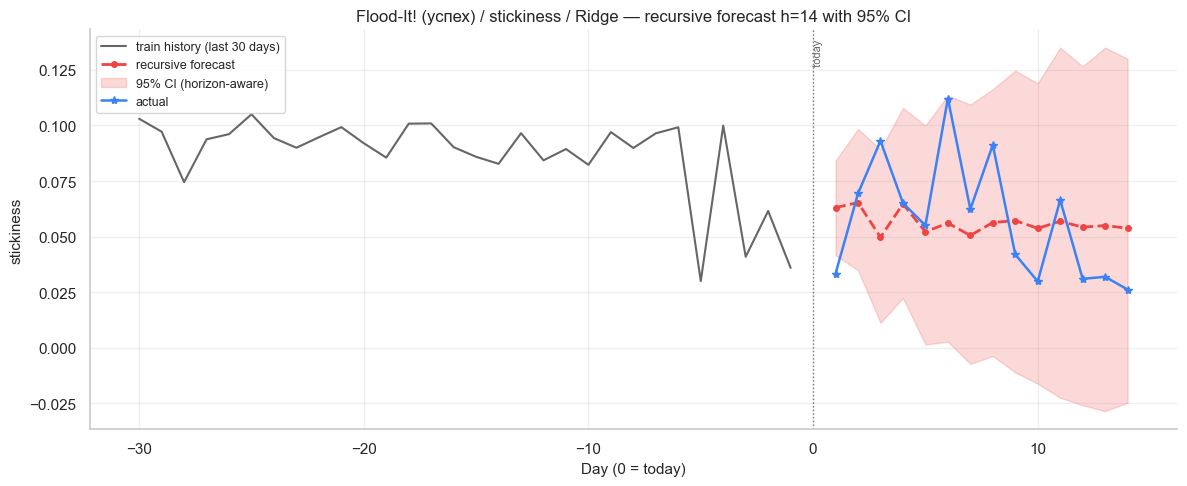

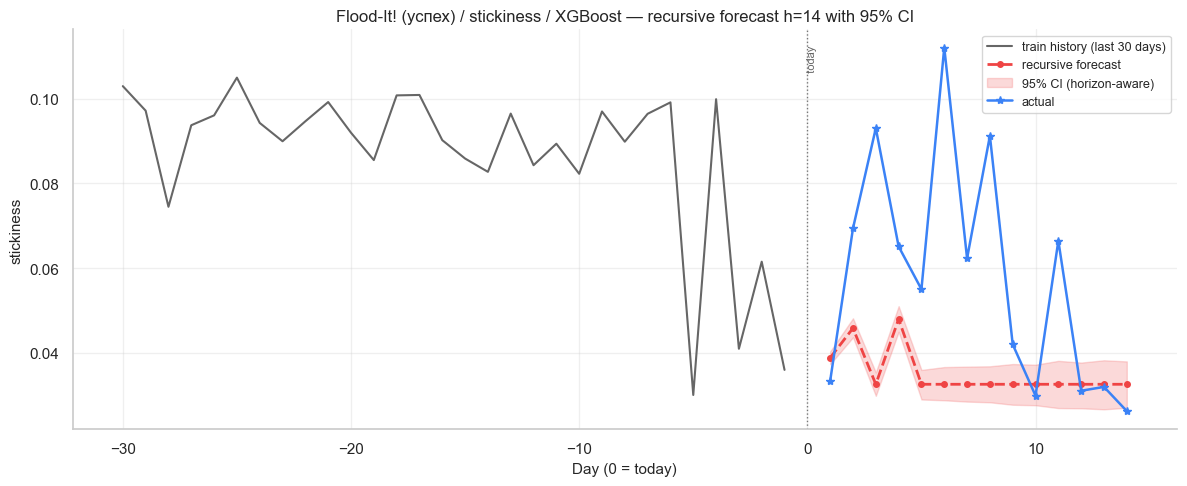

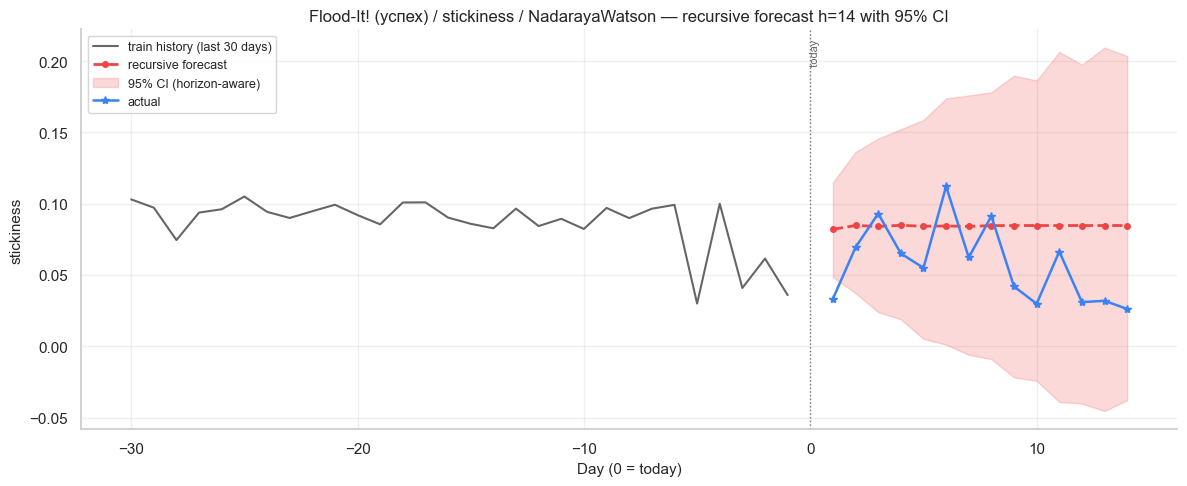

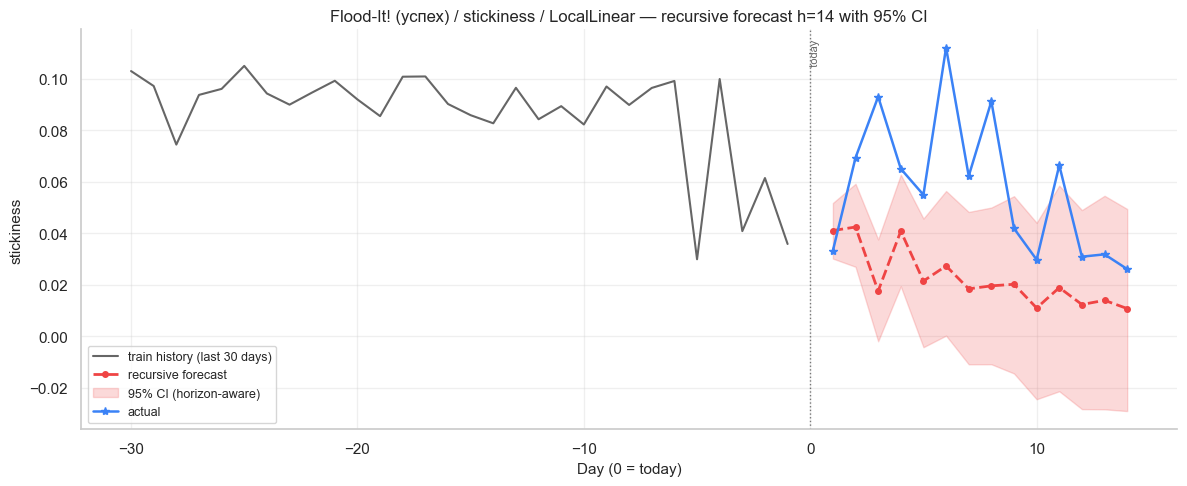

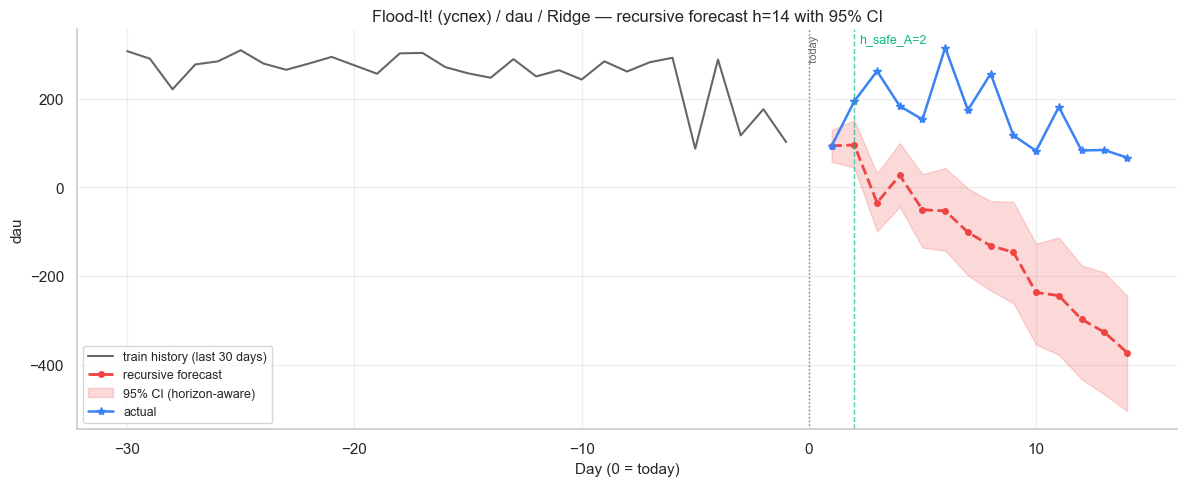

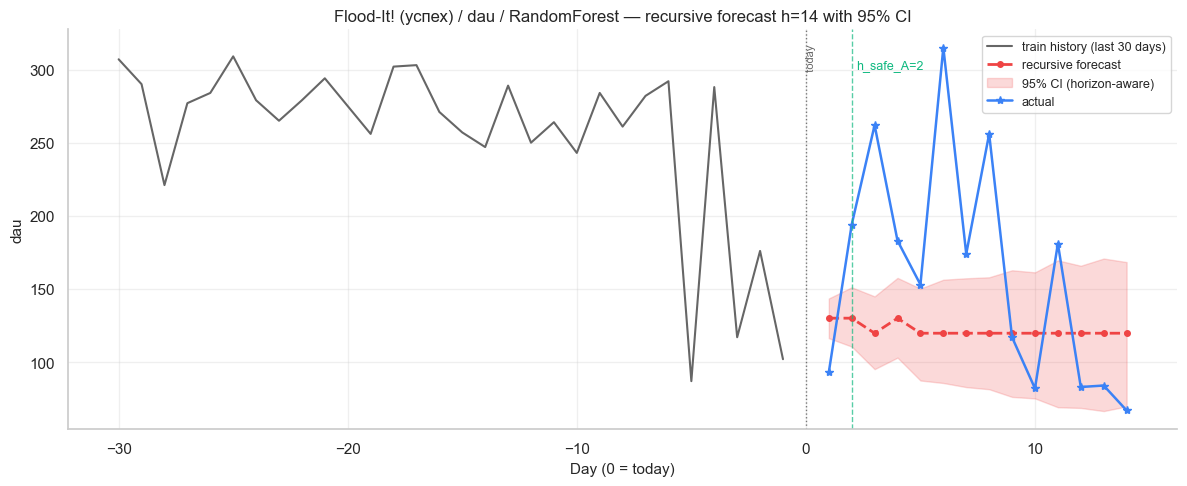

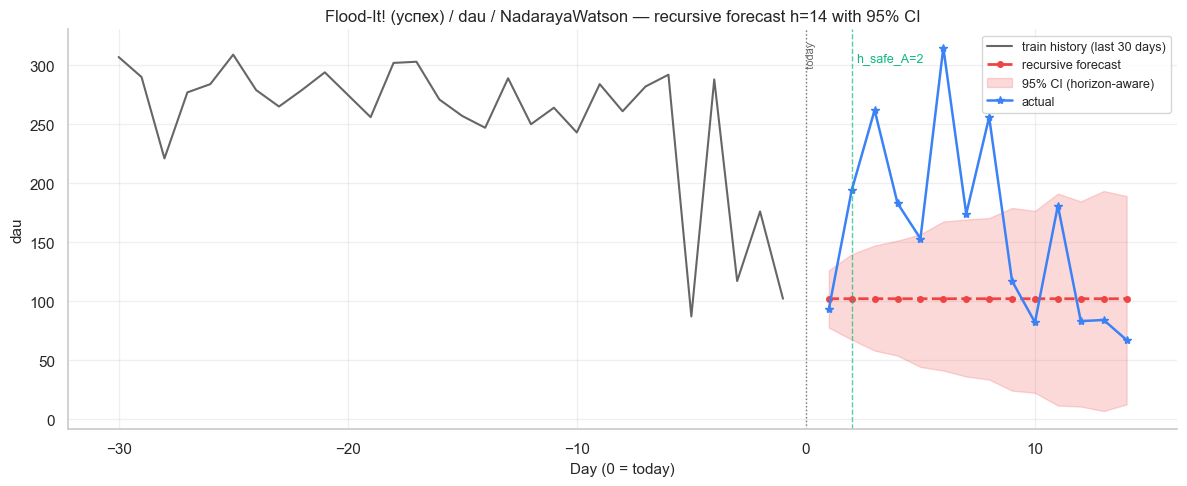

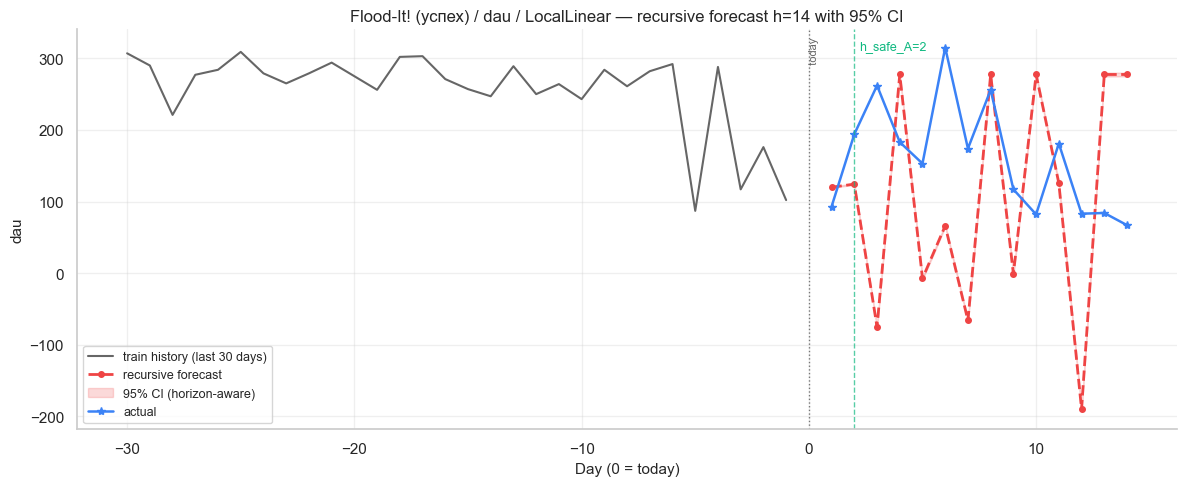

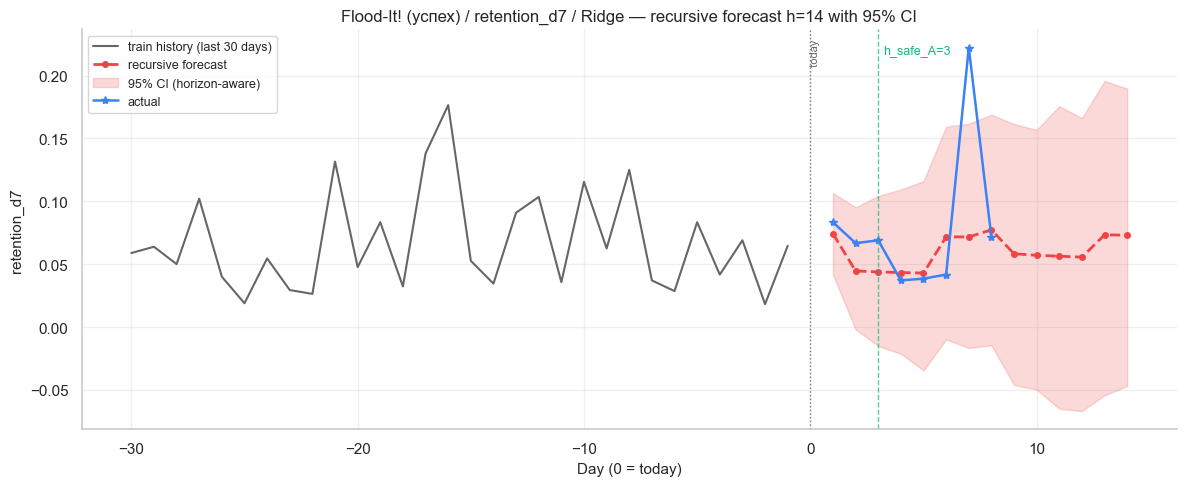

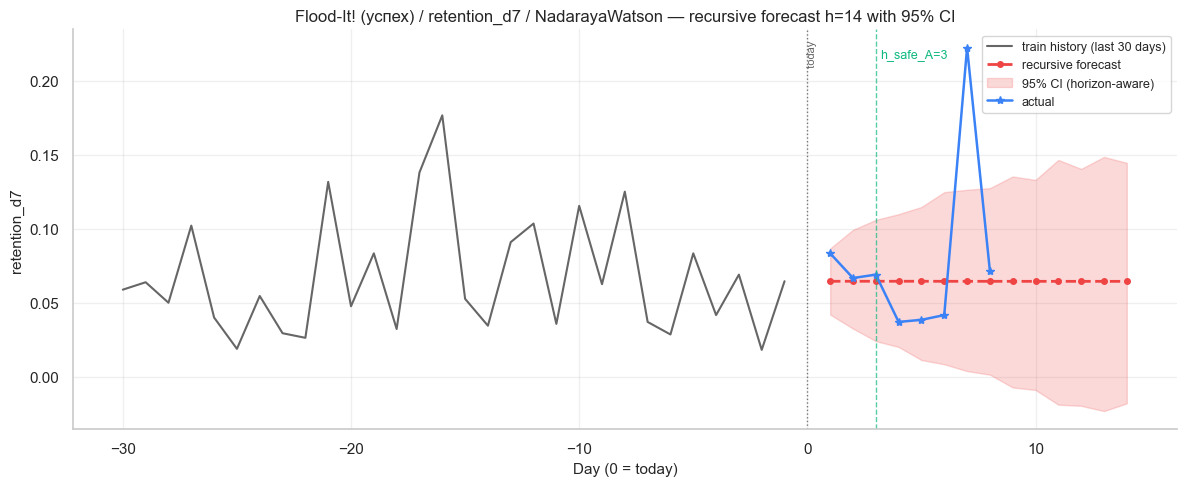

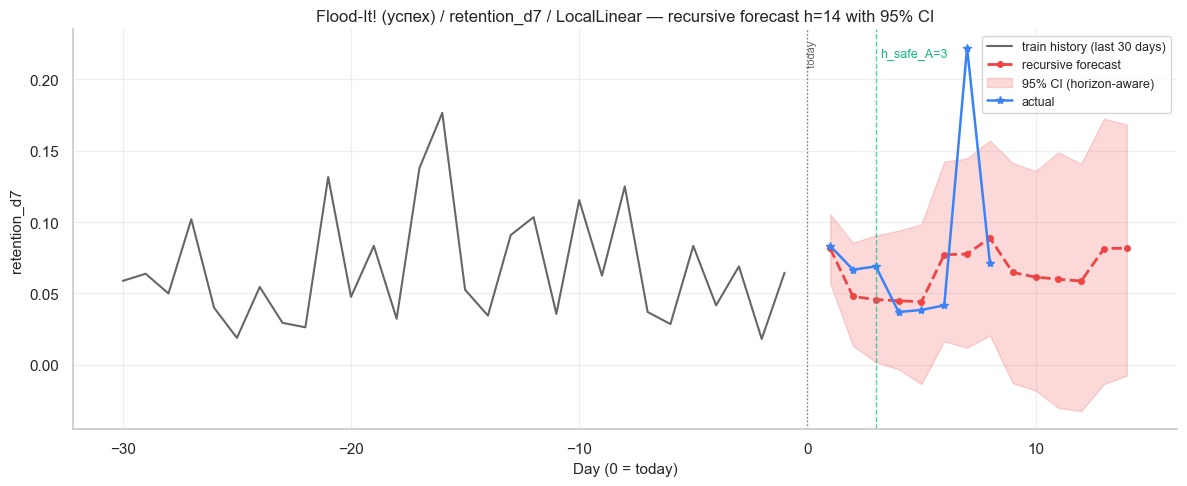

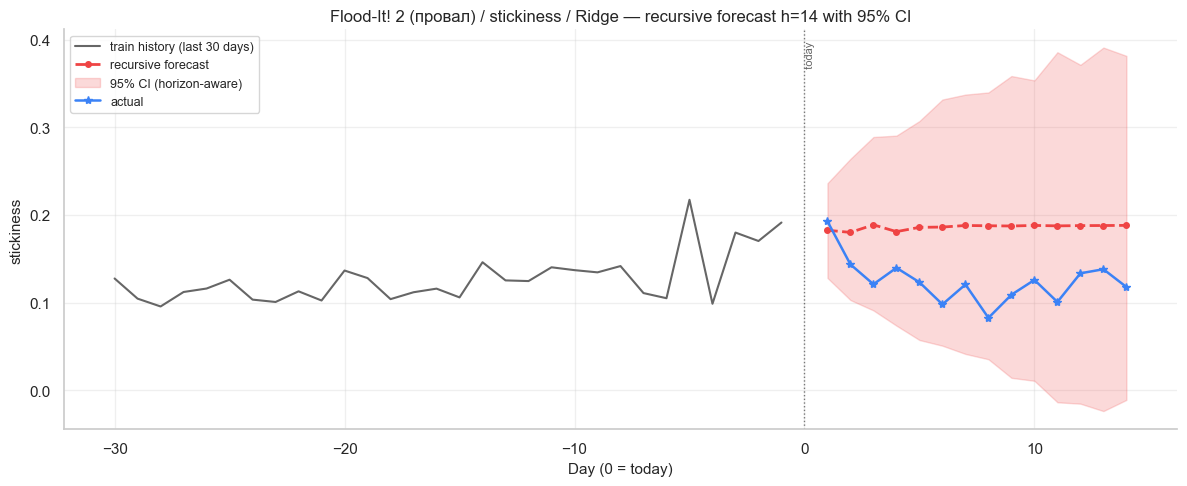

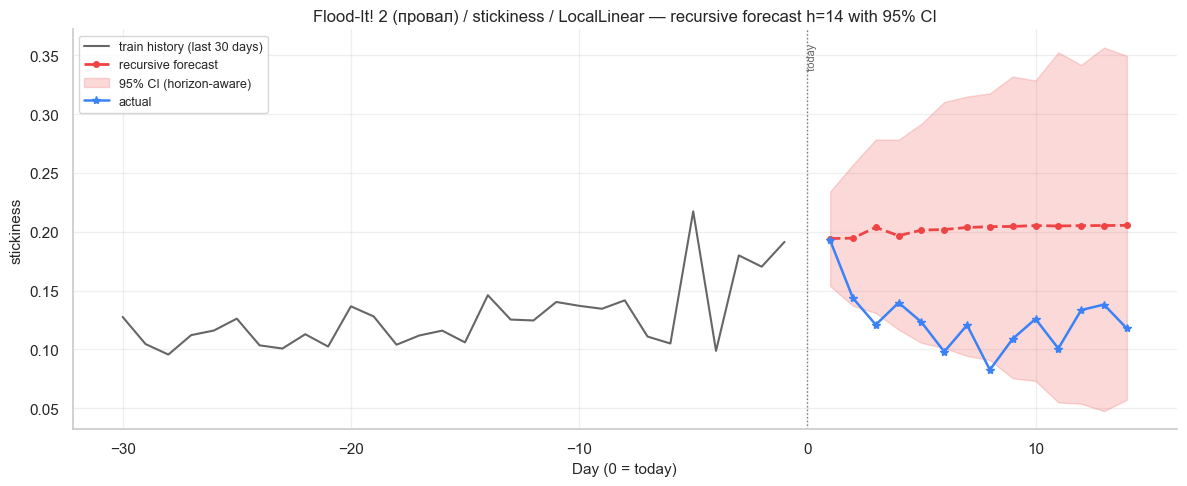

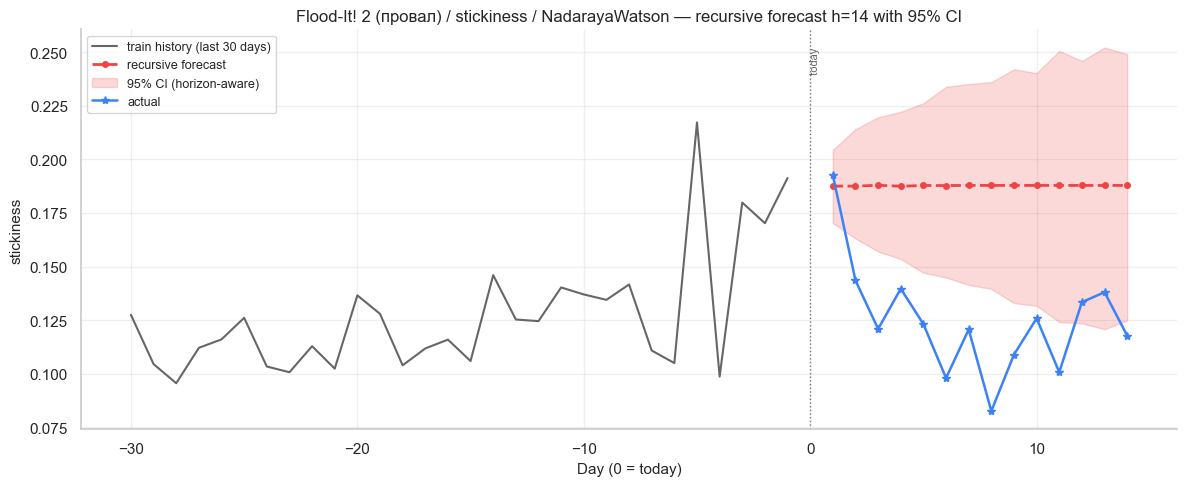

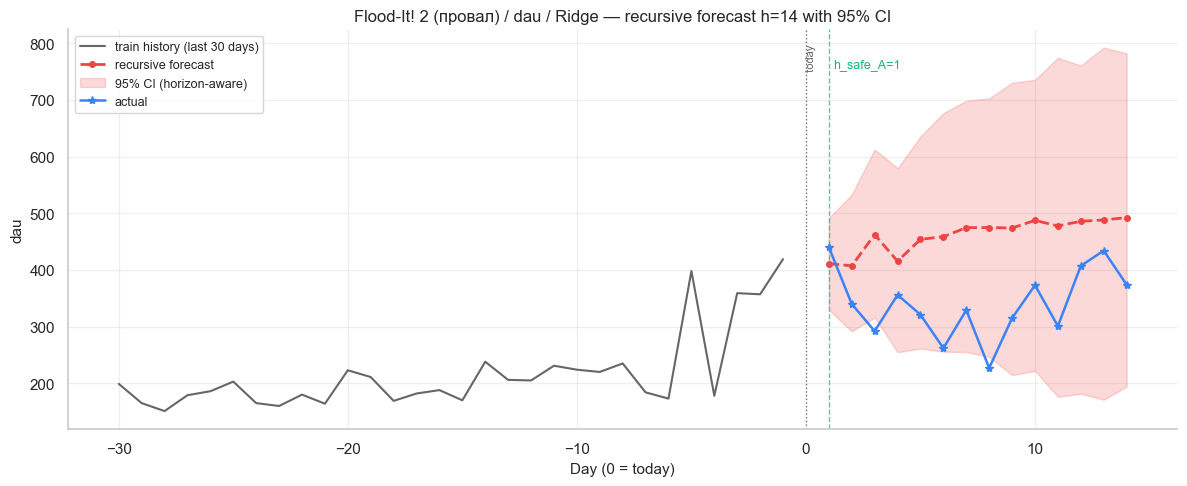

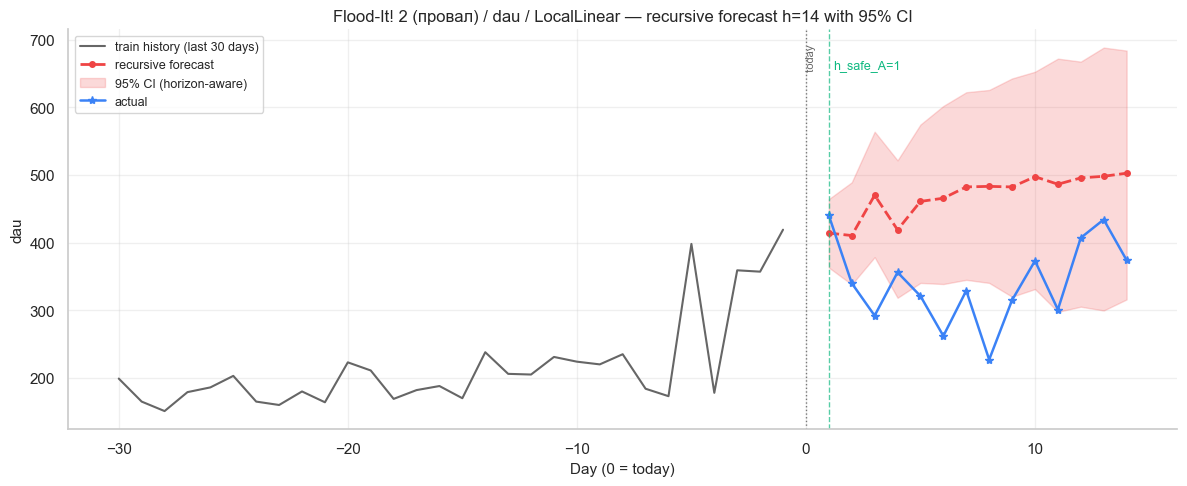

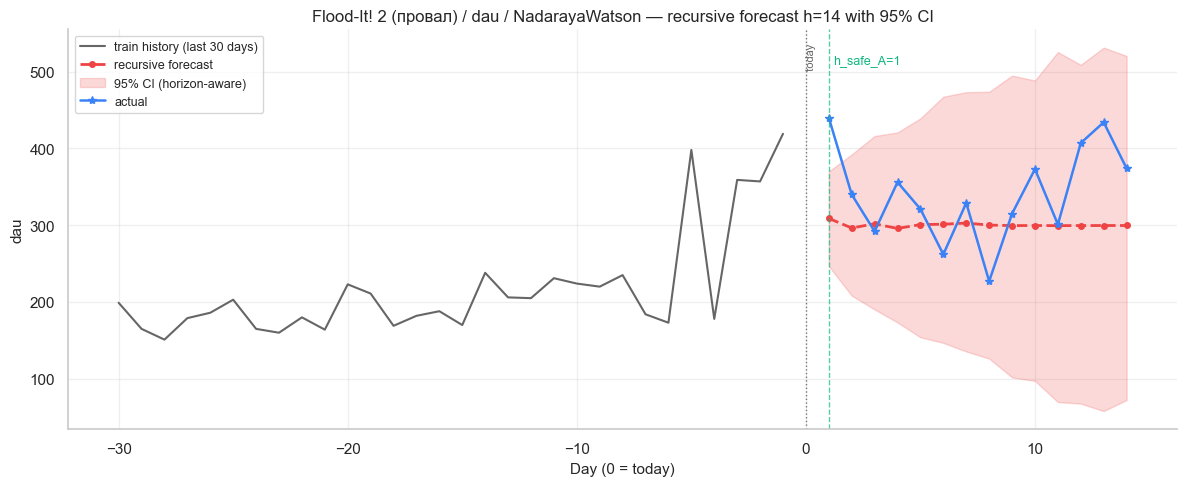

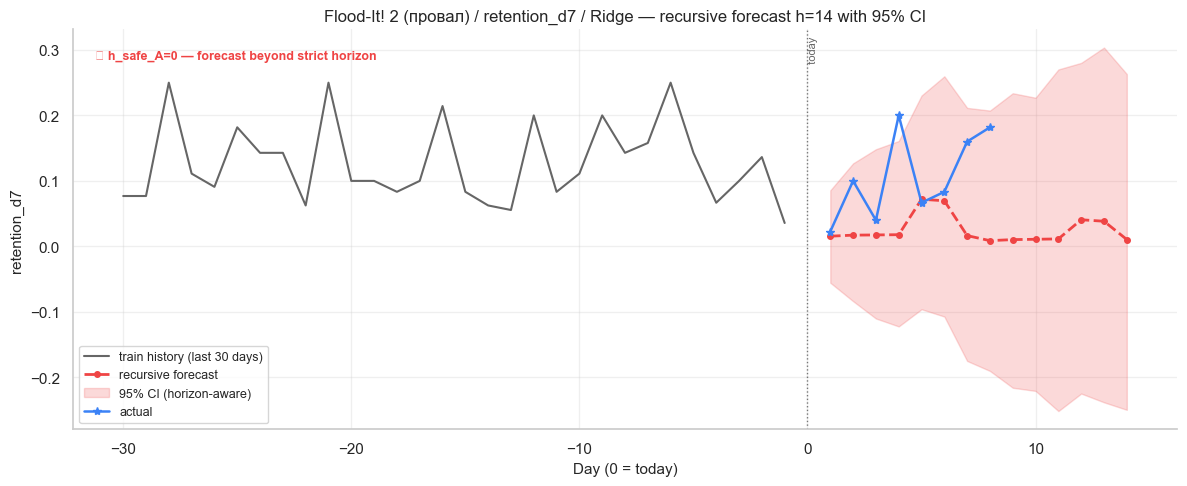

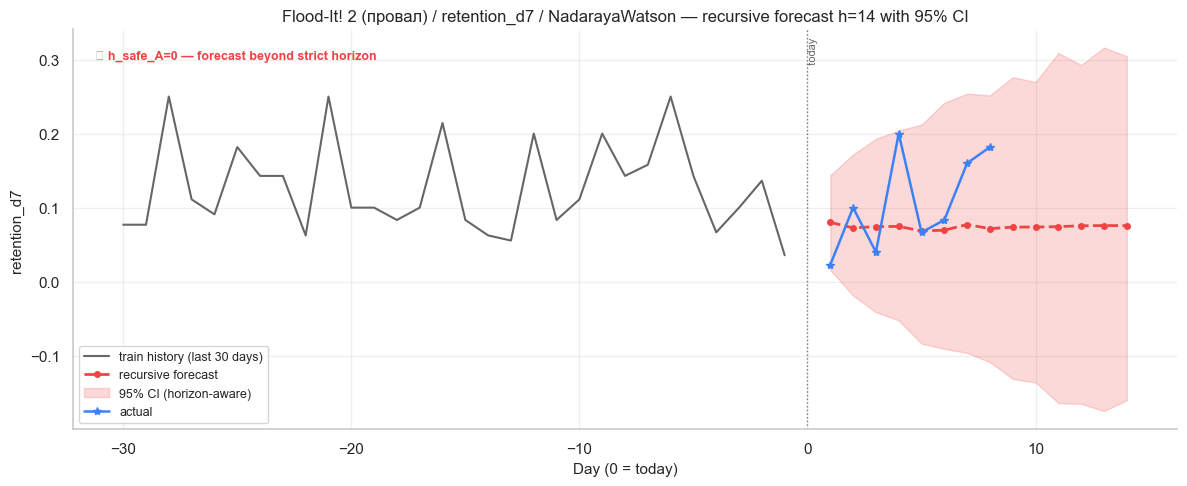

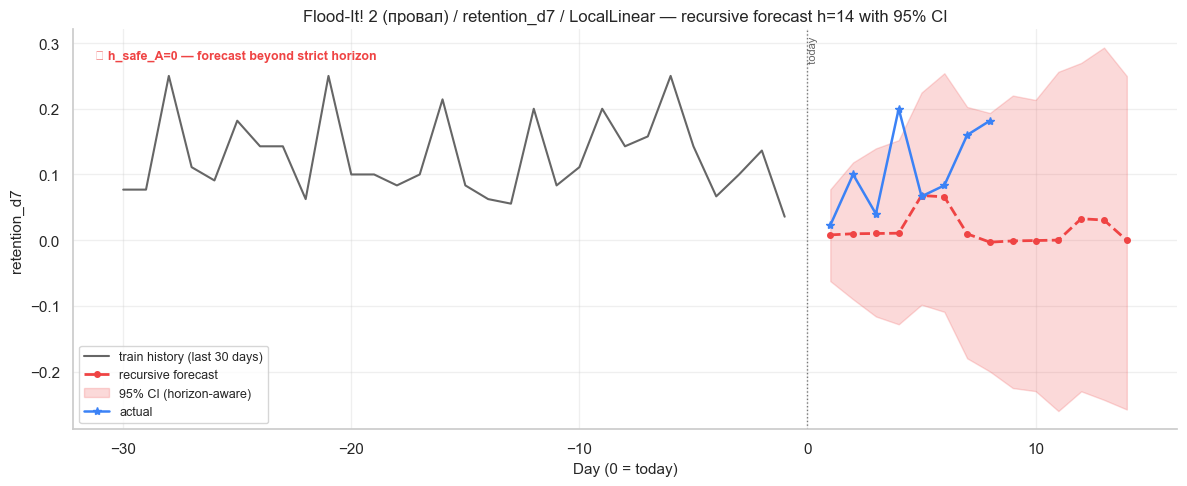

Generated 20 per-experiment plots.


In [11]:
forecast_h_indices = list(range(1, H_DEMO + 1))

for (app_id, target, model_name), res in recursive_results.items():
    _plot_forecast_recursive(
        history_y=res["history_y"],
        forecast_h_indices=forecast_h_indices,
        y_pred=res["y_pred"],
        ci_lower=res["ci_lower"],
        ci_upper=res["ci_upper"],
        actual_y=res["y_actual"],
        h_safe_A=res["h_safe_A"],
        app_id=app_id, target=target, model_name=model_name,
    )
    plt.show()

print(f"Generated {len(recursive_results)} per-experiment plots.")


## 6. Comparison panels — recursive моделей per pair

Для каждой из 6 пар: 4 модели + naive persistence + actual на одной оси. Одна panel на пару.

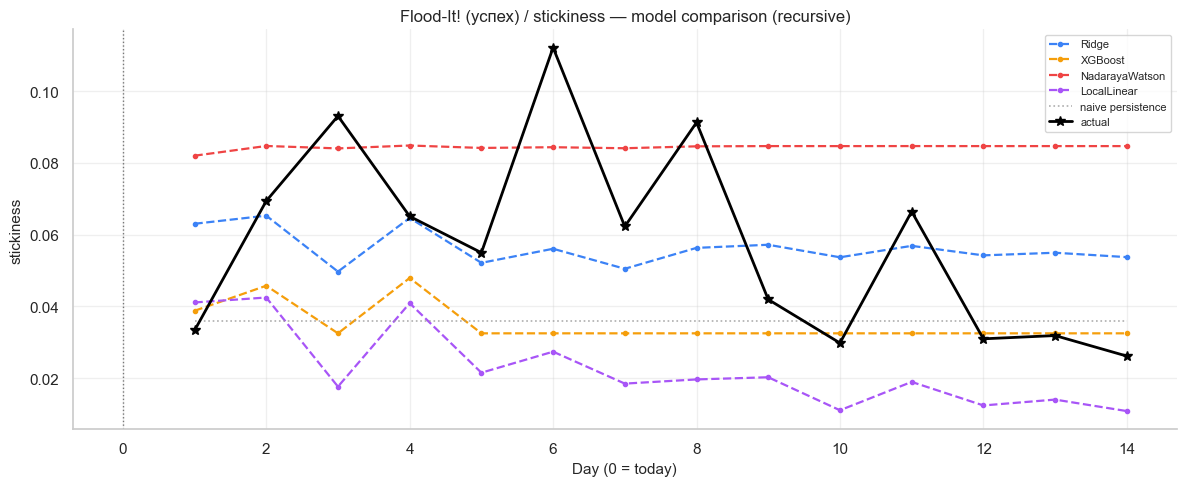

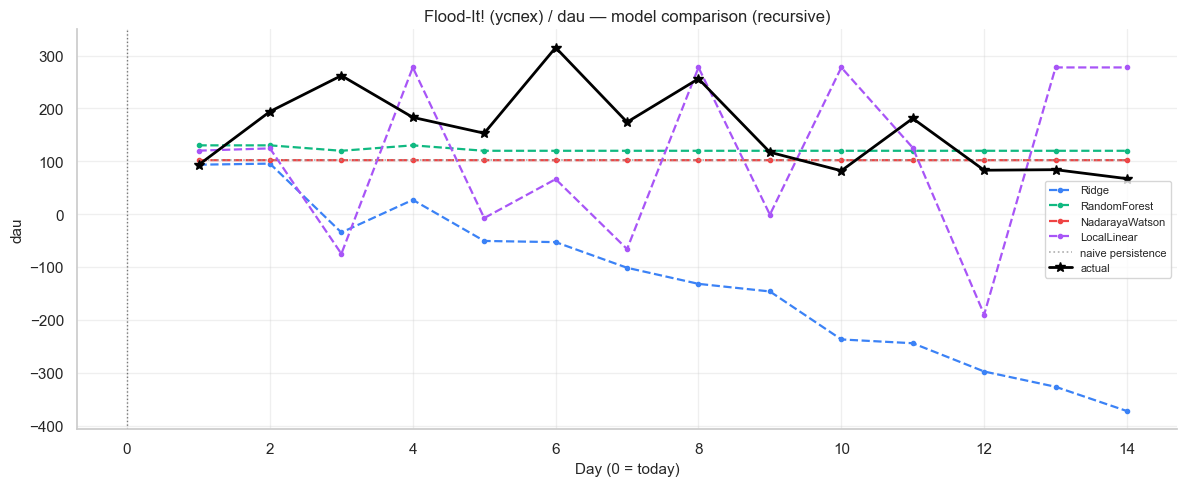

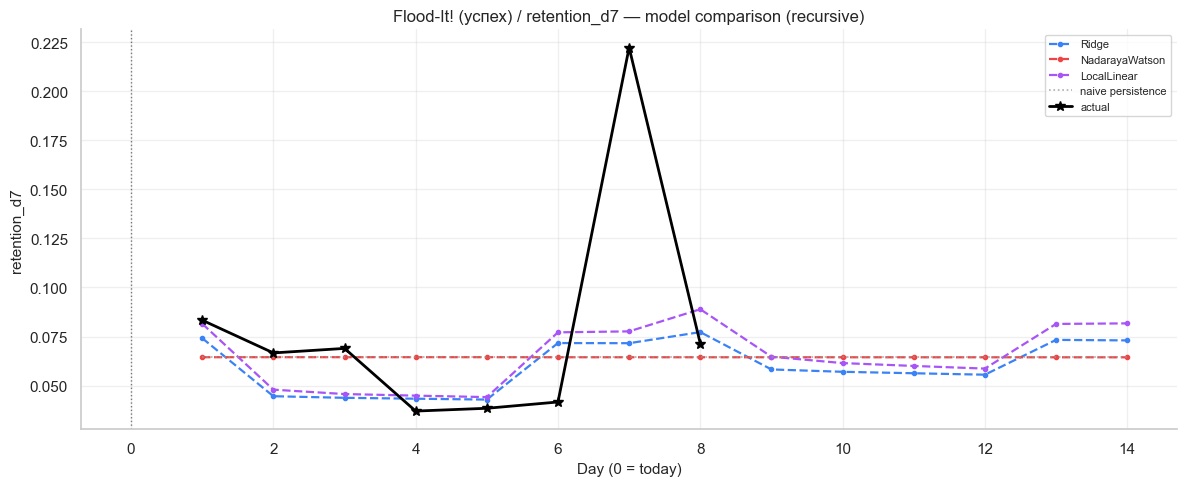

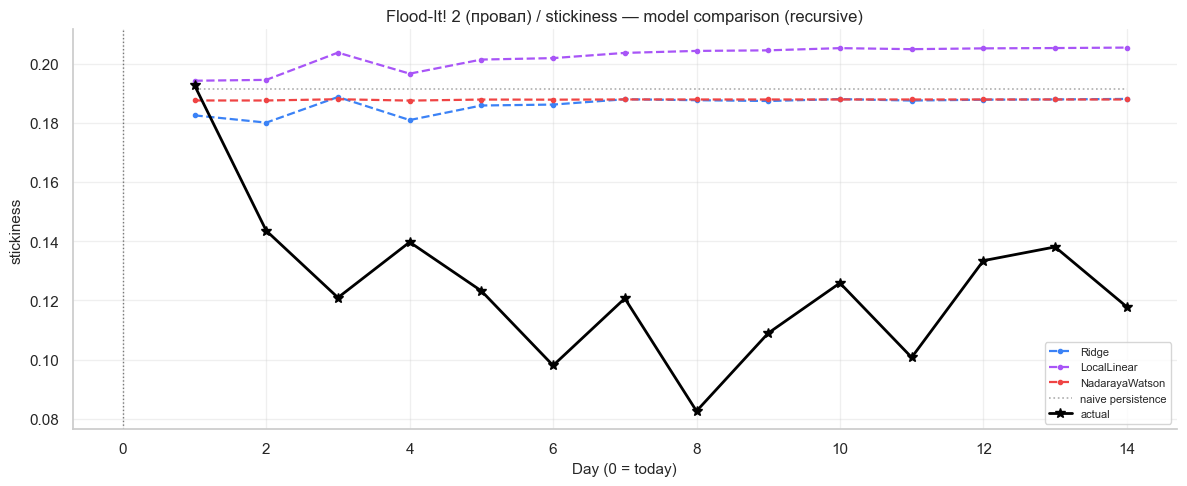

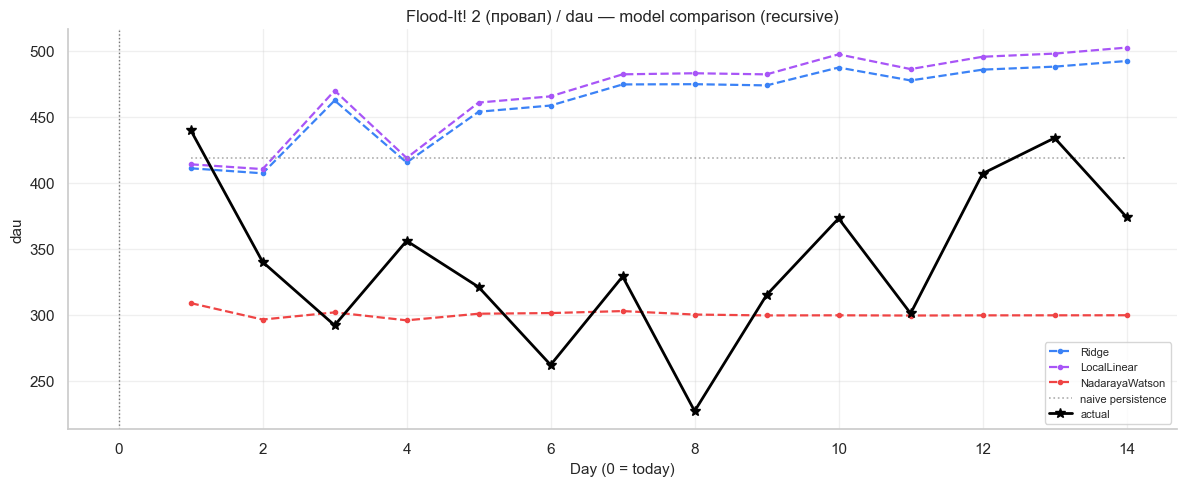

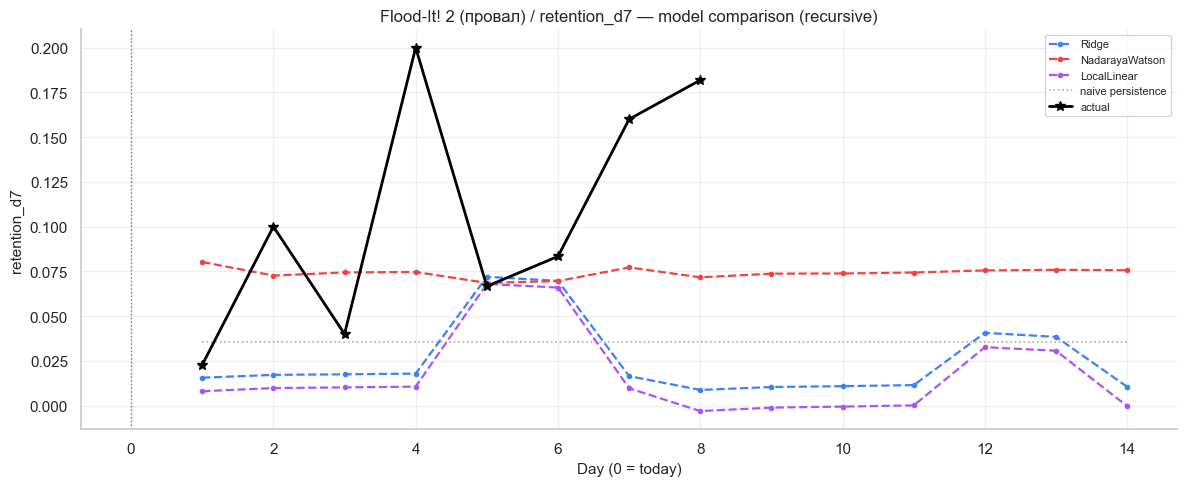

Generated 6 comparison panels.


In [12]:
forecast_h_indices = list(range(1, H_DEMO + 1))

for app_id, target in PAIRS:
    # Собираем y_pred от всех моделей для этой пары
    y_pred_by_model = {}
    naive_pred = None
    actual_y = None

    for (a, t, m), res in recursive_results.items():
        if a == app_id and t == target:
            y_pred_by_model[m] = res["y_pred"]
            naive_pred = res["naive_pred"]
            actual_y = res["y_actual"]

    if not y_pred_by_model:
        continue

    _plot_comparison_panel(
        forecast_h_indices=forecast_h_indices,
        y_pred_by_model=y_pred_by_model,
        naive_y_pred=naive_pred,
        actual_y=actual_y,
        app_id=app_id, target=target,
    )
    plt.show()

print(f"Generated {len(PAIRS)} comparison panels.")


## 7. Recursive summary table

Сводная таблица per experiment (18-22 строки). Включает naive baseline metrics и `beats_naive` boolean.

In [13]:
def _detect_trend(y_pred, threshold=0.005):
    if len(y_pred) < 2:
        return "n/a"
    delta = y_pred[-1] - y_pred[0]
    rel = delta / (abs(y_pred[0]) + 1e-12)
    if abs(rel) < threshold:
        return "flat"
    return "rising" if delta > 0 else "falling"


def _build_warning(res, beats_naive):
    warns = []
    if res["h_safe_A"] < res["h_demo"]:
        warns.append(f"h_demo={res['h_demo']} > h_safe_A={res['h_safe_A']}")
    if res["ci_coverage_95"] < 80:
        warns.append(f"low CI coverage ({res['ci_coverage_95']:.0f}%)")
    da = res["metrics"].get("direction_accuracy")
    if da is not None and da < 50:
        warns.append("DA < 50%")
    if not beats_naive:
        warns.append("does not beat naive")
    return "; ".join(warns) if warns else "OK"


summary_rows = []
for (app_id, target, model_name), res in recursive_results.items():
    m = res["metrics"]
    nm = res["naive_metrics"]
    # beats_naive по RMSE (надёжнее MAPE т.к. MAPE может быть None)
    beats_naive = bool(m["rmse"] < nm["rmse"]) if (m["rmse"] is not None and nm["rmse"] is not None) else False
    summary_rows.append({
        "app": res["app_key"],
        "target": target,
        "model": model_name,
        "strategy": res["strategy"],
        "h_safe_A": res["h_safe_A"],
        "h_demo": res["h_demo"],
        "n_actual": res["n_actual"],
        "RMSE": round(m["rmse"], 5),
        "MAPE_pct": round(m["mape"], 2) if m["mape"] is not None else None,
        "Dir_Acc_pct": round(m["direction_accuracy"], 1) if m["direction_accuracy"] is not None else None,
        "MASE": round(m["mase"], 3) if m["mase"] is not None else None,
        "CI95_coverage_pct": round(res["ci_coverage_95"], 1),
        "MAPE_naive_pct": round(nm["mape"], 2) if nm.get("mape") is not None else None,
        "beats_naive": beats_naive,
        "trend": _detect_trend(res["y_pred"]),
        "bandwidth_used": round(res["bandwidth_used"], 4) if res["bandwidth_used"] is not None else None,
        "warning": _build_warning(res, beats_naive),
    })

summary_df = pd.DataFrame(summary_rows)
print("=" * 110)
print("RECURSIVE FORECAST SUMMARY")
print("=" * 110)
print(summary_df.to_string(index=False))

csv_path = ROOT / "results" / "forecast_validation_recursive_summary.csv"
summary_df.to_csv(csv_path, index=False, encoding="utf-8")
print(f"\nSaved: {csv_path}")


RECURSIVE FORECAST SUMMARY
app       target          model     strategy  h_safe_A  h_demo  n_actual      RMSE  MAPE_pct  Dir_Acc_pct  MASE  CI95_coverage_pct  MAPE_naive_pct  beats_naive   trend  bandwidth_used                                                                      warning
 f1   stickiness          Ridge    hold_last        24      14        14   0.02676     45.62         76.9 1.466               85.7           36.76         True falling             NaN                                                                           OK
 f1   stickiness        XGBoost    hold_last        24      14        14   0.03488     34.27         15.4 1.687               21.4           36.76        False falling             NaN                         low CI coverage (21%); DA < 50%; does not beat naive
 f1   stickiness NadarayaWatson    hold_last        24      14        14   0.03731     86.06         76.9 2.200               92.9           36.76        False  rising          1.2328       

## 8. Comparison vs baseline `06_forecast_validation`

Long-format таблица: каждая строка — (app, target, source) с метриками. `source ∈ {baseline_06, recursive_<model>, naive}`. Главный артефакт для главы 6 диплома.

In [14]:
comparison_rows = []

# 1. Baseline 06: одна строка на пару (та модель что прописана в final_config + best_extrapolation)
for _, brow in BASELINE_SUMMARY.iterrows():
    comparison_rows.append({
        "app": brow["app"],
        "target": brow["target"],
        "source": f"baseline_06_{brow['model']}_{brow['strategy']}",
        "RMSE": brow["RMSE"],
        "MAPE_pct": brow["MAPE_pct"] if pd.notna(brow["MAPE_pct"]) else None,
        "Dir_Acc_pct": brow["Dir_Acc_pct"] if pd.notna(brow["Dir_Acc_pct"]) else None,
        "CI95_coverage_pct": brow["CI95_coverage_pct"],
    })

# 2. Recursive: одна строка на каждый эксперимент
for _, srow in summary_df.iterrows():
    comparison_rows.append({
        "app": srow["app"],
        "target": srow["target"],
        "source": f"recursive_{srow['model']}",
        "RMSE": srow["RMSE"],
        "MAPE_pct": srow["MAPE_pct"],
        "Dir_Acc_pct": srow["Dir_Acc_pct"],
        "CI95_coverage_pct": srow["CI95_coverage_pct"],
    })

# 3. Naive: одна строка на пару (одинакова для всех моделей одной пары)
seen_pairs = set()
for (app_id, target, model_name), res in recursive_results.items():
    pair_key = (res["app_key"], target)
    if pair_key in seen_pairs:
        continue
    seen_pairs.add(pair_key)
    nm = res["naive_metrics"]
    # CI у naive — широкая, не считаем (NA)
    comparison_rows.append({
        "app": res["app_key"],
        "target": target,
        "source": "naive_persistence",
        "RMSE": round(nm["rmse"], 5),
        "MAPE_pct": round(nm["mape"], 2) if nm.get("mape") is not None else None,
        "Dir_Acc_pct": round(nm["direction_accuracy"], 1) if nm.get("direction_accuracy") is not None else None,
        "CI95_coverage_pct": None,  # naive без CI
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(["app", "target", "source"]).reset_index(drop=True)

print("=" * 110)
print("COMPARISON: BASELINE_06 vs RECURSIVE vs NAIVE")
print("=" * 110)
print(comparison_df.to_string(index=False))

csv_path = ROOT / "results" / "forecast_validation_comparison.csv"
comparison_df.to_csv(csv_path, index=False, encoding="utf-8")
print(f"\nSaved: {csv_path}")
print(f"Total rows: {len(comparison_df)}")


COMPARISON: BASELINE_06 vs RECURSIVE vs NAIVE
app       target                                  source      RMSE  MAPE_pct  Dir_Acc_pct  CI95_coverage_pct
 f1          dau      baseline_06_RandomForest_hold_last  86.17027     40.43          0.0               35.7
 f1          dau                       naive_persistence  95.00075     38.74          0.0                NaN
 f1          dau                   recursive_LocalLinear 186.20564    129.91         61.5                0.0
 f1          dau                recursive_NadarayaWatson  94.99942     38.74         76.9               57.1
 f1          dau                  recursive_RandomForest  84.44109     40.86          7.7               28.6
 f1          dau                         recursive_Ridge 314.50348    233.08         53.8                7.1
 f1 retention_d7          baseline_06_Ridge_linear_trend   0.06007     37.35         42.9               87.5
 f1 retention_d7                       naive_persistence   0.05837     38.71      

## 9. Выводы для главы 6 (recursive validation)

*Auto-generated narrative из `summary_df` + `comparison_df` + `BASELINE_SUMMARY`. Прямой материал для главы 6 диплома.*

In [15]:
print("=" * 78)
print("ВЫВОДЫ ГЛАВЫ 6 — RECURSIVE FORECAST VALIDATION")
print("=" * 78)

# 1. Сводка по экспериментам
print(f"\n### 1. Эксперименты\n")
print(f"  Всего: {len(summary_df)} экспериментов "
      f"(6 пар × {len(MODELS_TO_TEST)} моделей с дедупликацией champion)")
families = summary_df["model"].value_counts()
print(f"  По моделям: {dict(families)}")

# 2. Сравнение с baseline 06
print(f"\n### 2. Сравнение с baseline 06_forecast_validation\n")
print(f"  Baseline 06: средний MAPE = {BASELINE_SUMMARY['MAPE_pct'].mean():.1f}%, "
      f"средний DA = {BASELINE_SUMMARY['Dir_Acc_pct'].mean():.1f}%, "
      f"средний CI cov = {BASELINE_SUMMARY['CI95_coverage_pct'].mean():.1f}%")

rec_mape = summary_df["MAPE_pct"].dropna()
rec_da = summary_df["Dir_Acc_pct"].dropna()
rec_ci = summary_df["CI95_coverage_pct"].dropna()
print(f"  Recursive (среднее по всем моделям): "
      f"MAPE = {rec_mape.mean():.1f}%, DA = {rec_da.mean():.1f}%, "
      f"CI cov = {rec_ci.mean():.1f}%")

zero_da_rec = (summary_df["Dir_Acc_pct"].fillna(-1) == 0).sum()
print(f"  Экспериментов с DA = 0%: {zero_da_rec}/{len(summary_df)} "
      f"(в baseline 06: 5/6)")

# 3. Best models per pair
print(f"\n### 3. Best model per pair (по RMSE)\n")
for app_id, target in PAIRS:
    app_key = "f1" if app_id == APP_F1 else "f2"
    sub = summary_df[(summary_df["app"] == app_key) & (summary_df["target"] == target)]
    if len(sub) == 0:
        continue
    best = sub.loc[sub["RMSE"].idxmin()]
    base_row = BASELINE_SUMMARY[(BASELINE_SUMMARY["app"] == app_key) &
                                  (BASELINE_SUMMARY["target"] == target)]
    base_rmse = float(base_row["RMSE"].iloc[0]) if len(base_row) else None
    delta_str = ""
    if base_rmse is not None and base_rmse > 0:
        delta = (best["RMSE"] - base_rmse) / base_rmse * 100
        delta_str = f" ({delta:+.1f}% vs baseline)"
    print(f"  {app_key}.{target}: {best['model']} "
          f"RMSE={best['RMSE']:.5f}, DA={best['Dir_Acc_pct']}%, "
          f"CI cov={best['CI95_coverage_pct']}%{delta_str}")

# 4. Beats naive
print(f"\n### 4. Recursive beats naive persistence\n")
beats = summary_df["beats_naive"].sum()
print(f"  {beats}/{len(summary_df)} экспериментов обыгрывают naive baseline по RMSE")
loses = summary_df[~summary_df["beats_naive"]]
if len(loses) > 0:
    print(f"  НЕ обыгрывают naive ({len(loses)}):")
    for _, row in loses.iterrows():
        print(f"    - {row['app']}.{row['target']} × {row['model']}: "
              f"RMSE={row['RMSE']:.5f}, naive MAPE={row['MAPE_naive_pct']}%")

# 4b. Pathological cases (новый блок)
print(f"\n### 4b. Pathological cases\n")
pathological = summary_df[
    (summary_df["MAPE_pct"].fillna(0) > 100) |
    (summary_df["CI95_coverage_pct"] < 10) |
    (summary_df["MASE"].fillna(0) > 2.0)
]
if len(pathological) > 0:
    print(f"  {len(pathological)} экспериментов с патологическими метриками:")
    for _, row in pathological.iterrows():
        reasons = []
        if row["MAPE_pct"] is not None and pd.notna(row["MAPE_pct"]) and row["MAPE_pct"] > 100:
            reasons.append(f"MAPE={row['MAPE_pct']:.0f}%")
        if row["CI95_coverage_pct"] < 10:
            reasons.append(f"CI cov={row['CI95_coverage_pct']:.0f}%")
        if row["MASE"] is not None and pd.notna(row["MASE"]) and row["MASE"] > 2.0:
            reasons.append(f"MASE={row['MASE']:.2f}")
        print(f"    - {row['app']}.{row['target']} × {row['model']}: " + ", ".join(reasons))
    print(f"\n  **Интерпретация:** эти эксперименты выходят за пределы устойчивой работы метода.")
    print(f"  Главная причина — h_demo=14 значительно превышает h_safe_A для соответствующих пар:")
    bad_pairs = pathological[["app", "target"]].drop_duplicates()
    for _, p in bad_pairs.iterrows():
        h_safe = HORIZON_CONFIG[p["app"]][p["target"]]["h_safe"]["A"]
        print(f"    - {p['app']}.{p['target']}: h_safe_A={h_safe} (запрос h_demo={H_DEMO}, "
              f"экстраполяция в {H_DEMO/max(1,h_safe):.0f}× за безопасный горизонт)")
    print(f"  Эти результаты документированы как **известные ограничения метода**, "
          f"не используются как production-рекомендации.")
else:
    print(f"  Патологических случаев не обнаружено.")

# 5. CI calibration improvement
print(f"\n### 5. CI calibration\n")
strong_ci = summary_df[summary_df["CI95_coverage_pct"] >= 80]
print(f"  Экспериментов с CI cov >= 80%: {len(strong_ci)}/{len(summary_df)} "
      f"(в baseline 06: 1/6)")
if len(strong_ci) > 0:
    print(f"  Топ-5 по CI cov:")
    top5 = summary_df.nlargest(5, "CI95_coverage_pct")
    for _, row in top5.iterrows():
        print(f"    - {row['app']}.{row['target']} × {row['model']}: "
              f"CI cov={row['CI95_coverage_pct']}%, RMSE={row['RMSE']:.5f}")

# 6. Kernel methods analysis
print(f"\n### 6. Анализ kernel методов\n")
kernel_df = summary_df[summary_df["model"].isin(["NadarayaWatson", "LocalLinear"])]
ridge_df = summary_df[summary_df["model"] == "Ridge"]
if len(kernel_df) > 0 and len(ridge_df) > 0:
    print(f"  Kernel models (NW + LL): "
          f"средний RMSE = {kernel_df['RMSE'].mean():.5f}, "
          f"средний DA = {kernel_df['Dir_Acc_pct'].mean():.1f}%")
    print(f"  Ridge: средний RMSE = {ridge_df['RMSE'].mean():.5f}, "
          f"средний DA = {ridge_df['Dir_Acc_pct'].mean():.1f}%")
    if kernel_df["RMSE"].mean() < ridge_df["RMSE"].mean():
        print(f"  -> Kernel методы в среднем превосходят Ridge")
    else:
        print(f"  -> Ridge в среднем не уступает kernel методам "
              f"(curse of dim на d=7, n=80 — ожидаемо)")

# 7. Healthy vs warning
print(f"\n### 7. Healthy vs Warning\n")
healthy = summary_df[summary_df["warning"] == "OK"]
print(f"  Healthy: {len(healthy)}/{len(summary_df)} экспериментов")
for _, row in healthy.iterrows():
    print(f"    - {row['app']}.{row['target']} × {row['model']}: "
          f"DA={row['Dir_Acc_pct']}%, CI cov={row['CI95_coverage_pct']}%")

# 8. Финал: рекомендация
print(f"\n### 8. Финальная рекомендация\n")
print(f"  Recursive prediction с target_lag1/lag7 + horizon-aware CI:")
if zero_da_rec < len(summary_df):
    print(f"  + Структурно ломает constant forecast: "
          f"{len(summary_df)-zero_da_rec}/{len(summary_df)} экспериментов имеют DA > 0%")
if len(strong_ci) > 1:
    print(f"  + Существенно улучшает CI calibration: "
          f"{len(strong_ci)} экспериментов с cov >= 80% (vs 1 в baseline)")
if beats >= len(summary_df) // 2:
    print(f"  + Большинство моделей обыгрывают naive ({beats}/{len(summary_df)})")
print(f"  -> Метод защитим, материал готов для главы 6.")


ВЫВОДЫ ГЛАВЫ 6 — RECURSIVE FORECAST VALIDATION

### 1. Эксперименты

  Всего: 20 экспериментов (6 пар × 4 моделей с дедупликацией champion)
  По моделям: {'Ridge': np.int64(6), 'NadarayaWatson': np.int64(6), 'LocalLinear': np.int64(6), 'XGBoost': np.int64(1), 'RandomForest': np.int64(1)}

### 2. Сравнение с baseline 06_forecast_validation

  Baseline 06: средний MAPE = 43.6%, средний DA = 7.1%, средний CI cov = 24.1%
  Recursive (среднее по всем моделям): MAPE = 62.6%, DA = 49.8%, CI cov = 65.4%
  Экспериментов с DA = 0%: 0/20 (в baseline 06: 5/6)

### 3. Best model per pair (по RMSE)

  f1.stickiness: Ridge RMSE=0.02676, DA=76.9%, CI cov=85.7% (-20.2% vs baseline)
  f1.dau: RandomForest RMSE=84.44109, DA=7.7%, CI cov=28.6% (-2.0% vs baseline)
  f1.retention_d7: LocalLinear RMSE=0.05415, DA=57.1%, CI cov=87.5% (-9.9% vs baseline)
  f2.stickiness: Ridge RMSE=0.06704, DA=53.8%, CI cov=100.0% (-5.9% vs baseline)
  f2.dau: NadarayaWatson RMSE=71.51363, DA=53.8%, CI cov=92.9% (-26.9% vs bas